# Progressive Projection

## Dependencies

In [1]:
import os
import glob
import numpy as np
import rasterio
import rasterio.mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.windows import Window
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject, transform_bounds
from rasterio.features import rasterize
from scipy.ndimage import gaussian_filter, laplace
from dbfread import DBF
import pandas as pd
import matplotlib.pyplot as plt
import tempfile
import subprocess
from plyfile import PlyData, PlyElement
import gpxpy
import pyproj
from shapely.geometry import LineString, Point
from shapely.ops import transform

## DEM Pre-processing

In this step, we get our DEM(s) together and onto the right CRS. The output is cropped to the largest rectangle containing no NoData cells.

In [9]:
# --- PARAMETERS ---
input_paths = glob.glob("../data/wurl/usgs_tiles/*.tif")  # Single file or list of files
output_path = "../data/wurl/processed_dem.tif"
target_crs = "EPSG:32143"  # Your desired output CRS
downsample_factor = 1.0  # 1.0 to skip

def largest_inner_rectangle(mask):
    h, w = mask.shape
    heights = np.zeros(w + 1, dtype=np.int32)
    best_rmin = best_cmin = best_rmax = best_cmax = 0
    max_area = 0
    for r in range(h):
        for c in range(w):
            if mask[r, c]:
                heights[c] += 1
            else:
                heights[c] = 0
        stack = [-1]
        for c in range(w + 1):
            while heights[c] < heights[stack[-1]]:
                h_val = heights[stack.pop()]
                left = stack[-1] + 1
                width = c - left
                area = h_val * width
                if area > max_area:
                    max_area = area
                    best_rmin = r - h_val + 1
                    best_cmin = left
                    best_rmax = r + 1
                    best_cmax = c
            stack.append(c)
    return best_rmin, best_cmin, best_rmax, best_cmax

opened_files = []
try:
    # 1. Mosaic / Load
    if len(input_paths) == 1:
        src = rasterio.open(input_paths[0])
        opened_files.append(src)
    else:
        opened_files = [rasterio.open(p) for p in input_paths]
        mosaic_array, mosaic_transform = merge(opened_files)
        profile = opened_files[0].profile.copy()
        profile.update({"height": mosaic_array.shape[1], "width": mosaic_array.shape[2], "transform": mosaic_transform})
        memfile = MemoryFile()
        src = memfile.open(**profile)
        src.write(mosaic_array)
        opened_files.extend([memfile, src])

    # 2. Downsample (optional)
    if downsample_factor != 1.0:
        new_h, new_w = int(src.height / downsample_factor), int(src.width / downsample_factor)
        ds_transform = src.transform * src.transform.scale((src.width / new_w), (src.height / new_h))
        ds_data = src.read(out_shape=(src.count, new_h, new_w), resampling=Resampling.bilinear)
        profile = src.profile.copy()
        profile.update({"height": new_h, "width": new_w, "transform": ds_transform})
        memfile_ds = MemoryFile()
        src = memfile_ds.open(**profile)
        src.write(ds_data)
        opened_files.extend([memfile_ds, src])

    # 3. Reproject
    dst_crs = rasterio.crs.CRS.from_string(target_crs)
    transform, width, height = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
    profile = src.profile.copy()
    profile.update({'crs': dst_crs, 'transform': transform, 'width': width, 'height': height})
    memfile_repr = MemoryFile()
    src_repr = memfile_repr.open(**profile)
    for i in range(1, src.count + 1):
        reproject(rasterio.band(src, i), rasterio.band(src_repr, i), src_transform=src.transform, 
                  src_crs=src.crs, dst_transform=transform, dst_crs=dst_crs, resampling=Resampling.bilinear)
    opened_files.extend([memfile_repr, src_repr])

    # 4. Crop to largest valid rectangle
    band = src_repr.read(1)
    nodata = src_repr.nodata if src_repr.nodata is not None else 0
    valid_mask = (band != nodata)
    total_nodata_pre = int(np.sum(~valid_mask))
    print(f"Pre-crop dimensions: {src_repr.width}x{src_repr.height}")
    print(f"Pre-crop CRS: {src_repr.crs}")
    print(f"NoData cells before crop: {total_nodata_pre}")

    rmin, cmin, rmax, cmax = largest_inner_rectangle(valid_mask)
    window = Window(cmin, rmin, cmax - cmin, rmax - rmin)
    cropped_data = src_repr.read(window=window)
    cropped_transform = rasterio.windows.transform(window, src_repr.transform)

    # 5. Save Output
    final_profile = src_repr.profile.copy()
    final_profile.update({"height": cropped_data.shape[1], "width": cropped_data.shape[2], "transform": cropped_transform})
    with rasterio.open(output_path, "w", **final_profile) as dst:
        dst.write(cropped_data)

    print(f"Output dimensions: {cropped_data.shape[2]}x{cropped_data.shape[1]}")
    print(f"Output CRS: {dst_crs}")
    output_nodata = int(np.sum(cropped_data[0] == nodata))
    print(f"NoData cells in output: {output_nodata}")
    print("Processing completed successfully.")

finally:
    for f in reversed(opened_files):
        try: f.close()
        except: pass

Pre-crop dimensions: 6027x11619
Pre-crop CRS: EPSG:32143
NoData cells before crop: 1724269
Output dimensions: 5768x11548
Output CRS: EPSG:32143
NoData cells in output: 0
Processing completed successfully.


## Gather Accompanying Layers

### Bare Earth Color

Use the USDA NRCS Soil Colors of the United States dataset. Reproject, resample, and crop to match DEM.

In [10]:
# --- PARAMETERS ---
template_path = "../data/wurl/processed_dem.tif"
source_path = "../data/soil_color/US-soil-color-010cm-gNATSGO-highres.tif"
output_path = "../data/wurl/aligned_soil_raster.tif"

# --- PROCESSING ---
with rasterio.open(template_path) as template:
    # Extract the exact target profile metrics from your template TIF
    target_profile = template.profile.copy()
    target_crs = template.crs
    target_transform = template.transform
    target_width = template.width
    target_height = template.height
    
    # Ensure the output profile matches your template's data layout
    # Classification rasters typically use integers (e.g., uint8 or uint16)
    # We read the data type directly from your source class raster
    with rasterio.open(source_path) as source:
        source_dtype = source.dtypes[0]
        source_nodata = source.nodata if source.nodata is not None else 0
        
        target_profile.update({
            'dtype': source_dtype,
            'nodata': source_nodata,
            'count': 1
        })

        # Create the output file with the template's exact configurations
        with rasterio.open(output_path, 'w', **target_profile) as dst:
            
            print(f"Resampling categorical raster: {source_path}...")
            print(f"Target dimensions: {target_width}x{target_height}")
            print(f"Data Type preserved: {source_dtype}")

            # Reproject/Resample the data manually
            reproject(
                source=rasterio.band(source, 1),
                destination=rasterio.band(dst, 1),
                src_transform=source.transform,
                src_crs=source.crs,
                dst_transform=target_transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest,
                dst_nodata=source_nodata
            )
            
print(f"SUCCESS: Pixel-perfect aligned class file written to {output_path}")

Resampling categorical raster: ../data/soil_color/US-soil-color-010cm-gNATSGO-highres.tif...
Target dimensions: 5768x11548
Data Type preserved: uint16
SUCCESS: Pixel-perfect aligned class file written to ../data/wurl/aligned_soil_raster.tif


### Trail

This step is entirely optional. But if you have a GPX of a trail you'd like to include, we need to turn it into a mask for land cover and a polyline for rendering.

In [ ]:
# --- PARAMETERS ---
DEM_PATH = "../data/wurl/processed_dem.tif"
GPX_PATH = "../data/trails/WURL_Wasatch_Ultimate_Ridge_Linkup.gpx"
TRAIL_MASK_OUT = "../data/wurl/trail_mask.tif"
TRAIL_CENTERLINE_OUT = "../data/wurl/trail_centerline.npy"
CORRIDOR_WIDTH_PX = 2
SCALE = 0.001

# --- PROCESSING ---
# 1. Parse GPX
with open(GPX_PATH) as f:
    gpx = gpxpy.parse(f)

points = []
for track in gpx.tracks:
    for segment in track.segments:
        for pt in segment.points:
            points.append((pt.latitude, pt.longitude))

if not points:
    raise ValueError("No track points found in GPX.")

# 2. Open DEM for CRS / transform / shape
with rasterio.open(DEM_PATH) as src:
    dst_crs = src.crs
    dem_transform = src.transform
    height, width = src.height, src.width
    center_col, center_row = width // 2, height // 2
    x_center, y_center = dem_transform * (center_col, center_row)

# 3. Convert WGS84 to projected CRS
project = pyproj.Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
trail_utm = np.array([project.transform(lon, lat) for lat, lon in points])

# 4. Resample trail to one vertex per DEM pixel
dem_res_m = abs(dem_transform[0])
trail_line = LineString(trail_utm)
resampled = []
for d in np.arange(0, trail_line.length, dem_res_m):
    pt = trail_line.interpolate(d)
    resampled.append((pt.x, pt.y))
# Ensure endpoint is included
last_pt = (trail_utm[-1, 0], trail_utm[-1, 1])
if np.linalg.norm(np.array(resampled[-1]) - np.array(last_pt)) > dem_res_m * 0.5:
    resampled.append(last_pt)
trail_utm = np.array(resampled)
trail_line = LineString(trail_utm)

# 5. Rasterize corridor mask (CORRIDOR_WIDTH_PX DEM pixels wide)
corridor_width_m = CORRIDOR_WIDTH_PX * abs(dem_transform[0])
corridor = trail_line.buffer(corridor_width_m, cap_style=2, join_style=2)
trail_mask = rasterize(
    [(corridor, 1)],
    out_shape=(height, width),
    transform=dem_transform,
    default_value=0,
    dtype=np.uint8
)

# 6. Save mask as GeoTIFF
with rasterio.open(TRAIL_MASK_OUT, 'w',
    driver='GTiff', height=height, width=width, count=1,
    dtype=np.uint8, crs=dst_crs, transform=dem_transform) as dst:
    dst.write(trail_mask, 1)

# 7. Convert to mesh-space XY (for warp drive shrinkwrap)
xy = np.array([(p.x - x_center, p.y - y_center) for p in trail_line.coords]) * SCALE
np.save(TRAIL_CENTERLINE_OUT, xy.astype(np.float32))

print(f"Trail: {len(xy)} vertices, {int(np.sum(trail_mask))} corridor pixels.")
print(f"Mask: {TRAIL_MASK_OUT}")
print(f"Centerline: {TRAIL_CENTERLINE_OUT}")

### Land Cover

We procedurally generate land cover using slope, aspect, elevation, flow accumulation, and ecological knowledge. There are 3 land cover types: bare, grass, and forest. Each is expressed as a probability. These probabilities will later be added to each vertex.

DEM: 5768x11548, 28.8m resolution
Derivatives computed.
Predictors blurred.
Environmental fields built.
Scores computed.
Softmax done. Mean probs: forest=0.589, grass=0.263, bare=0.148
Trail clearance applied: 7019 pixels.
Exported: ../data/wurl/forest_density.tif
Exported: ../data/wurl/grass_density.tif
Exported: ../data/wurl/bare_density.tif


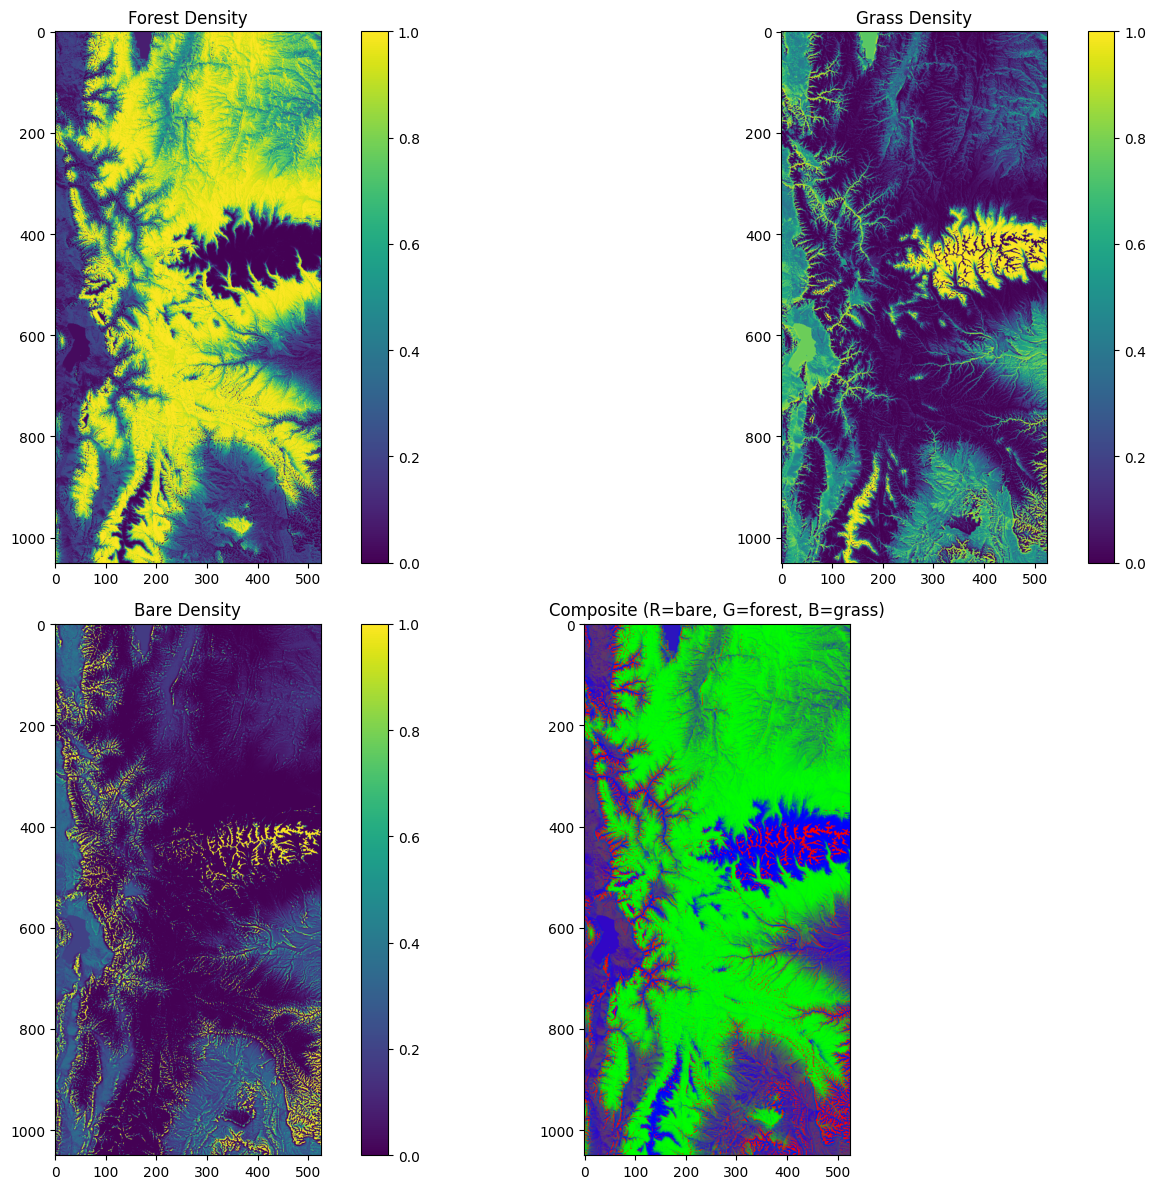


Land cover generation complete.


In [2]:
# --- PARAMETERS ---
DEM_PATH = "../data/wurl/processed_dem.tif"
TRAIL_MASK_PATH = "../data/wurl/trail_mask.tif"

FOREST_DENSITY_OUT = "../data/wurl/forest_density.tif"
GRASS_DENSITY_OUT = "../data/wurl/grass_density.tif"
BARE_DENSITY_OUT = "../data/wurl/bare_density.tif"

# Softmax temperature (lower = more decisive transitions)
TEMP = 0.3

# Elevation envelope centers and spreads (meters)
FOREST_CENTER  = 2550   # peak forest elevation
FOREST_SIGMA   = 600    # spread of forest zone
OPEN_CENTER    = 2900   # subalpine openings elevation
OPEN_SIGMA     = 500    # spread of subalpine zone
ALPINE_CENTER  = 3300   # alpine grass elevation
ALPINE_SIGMA   = 350    # spread of alpine grass
LOW_CENTER     = 1600   # desert flats elevation
LOW_SIGMA      = 500    # spread of desert flats
BARE_THRESH    = 3350   # bare sigmoid midpoint
BARE_STEEPNESS = 120    # bare sigmoid steepness

# Score weights (tune these for land cover proportions)
TREE_WEIGHT      = 2.5  # forest peak score
TREE_OPEN        = 1.0  # subalpine tree contribution
TREE_SOUTH_PEN   = 0.4  # south-facing penalty
TREE_SLOPE_PEN   = 0.3  # slope penalty multiplier
TREE_SLOPE_THRESH = 30  # slope threshold for penalty (degrees)

GRASS_LOW        = 0.6  # desert grass at valley floor
GRASS_OPEN       = 1.5  # subalpine grass
GRASS_ALPINE     = 2.0  # alpine grass peak
GRASS_SOUTH      = 0.3  # south-facing grass bonus
GRASS_MOIST_PEN  = 0.3  # moisture penalty (drier = more grass)

BARE_LOW         = 0.4  # desert bare at valley floor
BARE_ALPINE      = 2.0  # alpine bare peak
BARE_EXPOSURE    = 1.0  # exposed ridge bare (creates bare peaks below treeline)
BARE_SLOPE       = 0.3  # steep slope bare
BARE_SLOPE_THRESH = 35  # slope threshold for bare (degrees)

# Orographic moisture coefficients (west-facing = wetter in Utah)
MOIST_WEST   = 0.5  # westness contribution
MOIST_TPI    = 0.5  # TPI contribution (ridges = more orographic precip)
MOIST_BASE   = 0.5  # baseline moisture [0,1] — shift for moisture mapping

# Blur sigma per predictor (pixels at 30m)
BLUR = {"elev": 3, "slope": 2, "northness": 2,
        "tpi_100": 3, "tpi_500": 4, "curvature": 2}

# --- 1. LOAD DEM ---
with rasterio.open(DEM_PATH) as src:
    dem = src.read(1).astype(np.float64)
    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs
    res = abs(transform[0])
    nodata = src.nodata
    valid = dem != nodata if nodata is not None else np.ones_like(dem, dtype=bool)
    dem[~valid] = np.nan

h, w = dem.shape
print(f"DEM: {w}x{h}, {res:.1f}m resolution")

# --- 2. DERIVATIVES ---
dem_filled = np.where(np.isnan(dem), np.nanmean(dem), dem)

# Slope
gx, gy = np.gradient(dem_filled, res, res)
slope = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))

# Aspect -> northness
aspect = np.degrees(np.arctan2(-gy, -gx)) % 360
northness = np.cos(np.radians(aspect))

# Curvature (positive = convex)
curvature = laplace(dem_filled) * res**2

# TPI at two scales (pixels)
tpi_100 = dem_filled - gaussian_filter(dem_filled, sigma=100.0/res)
tpi_500 = dem_filled - gaussian_filter(dem_filled, sigma=500.0/res)

print("Derivatives computed.")

# --- 3. BLUR PREDICTORS ---
def blur(arr, sigma):
    if sigma <= 0: return arr.copy()
    return gaussian_filter(arr, sigma=sigma, mode='reflect')

elev_b   = blur(dem_filled, BLUR['elev'])
slope_b   = blur(slope, BLUR['slope'])
north_b   = blur(northness, BLUR['northness'])
aspect_b  = blur(aspect, BLUR['northness'])
curv_b    = blur(curvature, BLUR['curvature'])
tpi100_b  = blur(tpi_100, BLUR['tpi_100'])
tpi500_b  = blur(tpi_500, BLUR['tpi_500'])

print("Predictors blurred.")

# --- 4. BUILD ENVIRONMENTAL FIELDS ---
def zscore(x):
    m = np.nanmean(x)
    s = np.nanstd(x)
    return (x - m) / s if s > 0 else np.zeros_like(x)

# Exposure: 0.7 * TPI500 + 0.3 * TPI100 + convexity bonus
exposure_raw = (0.7 * zscore(tpi500_b) + 0.3 * zscore(tpi100_b) +
                0.3 * np.maximum(curv_b, 0) / (np.nanstd(curv_b) + 1e-6))
exposure = zscore(exposure_raw)

# Orographic moisture proxy (west-facing = wetter in Utah)
aspect_rad = np.radians(aspect_b)
westness = -np.sin(aspect_rad)  # positive = west-facing
orographic = (MOIST_WEST * zscore(westness) + MOIST_TPI * zscore(tpi500_b))
moisture = np.clip(MOIST_BASE + MOIST_BASE * orographic, 0, 1)

print("Environmental fields built.")

# --- 5. SCORES ---
# Elevation envelopes
low_env    = np.exp(-((elev_b - LOW_CENTER) / LOW_SIGMA)**2)    # desert flats
forest_env = np.exp(-((elev_b - FOREST_CENTER) / FOREST_SIGMA)**2)  # montane forest
open_env   = np.exp(-((elev_b - OPEN_CENTER) / OPEN_SIGMA)**2)    # subalpine openings
alpine_env = np.exp(-((elev_b - ALPINE_CENTER) / ALPINE_SIGMA)**2) # alpine grass
bare_env   = 1.0 / (1.0 + np.exp(-(elev_b - BARE_THRESH) / BARE_STEEPNESS))  # alpine bare

southness = np.clip(-north_b, 0, 1)

# Tree score: montane forest + subalpine, needs moisture, penalized on south slopes & steep
q_tree = (TREE_WEIGHT * forest_env * (MOIST_BASE + MOIST_BASE * moisture)
         + TREE_OPEN * open_env
         - TREE_SOUTH_PEN * southness
         - TREE_SLOPE_PEN * np.maximum(0, (slope_b - TREE_SLOPE_THRESH) / 15))

# Grass score: desert floor + subalpine + alpine, bonus on south slopes, less where wet
q_grass = (GRASS_LOW * low_env + GRASS_OPEN * open_env + GRASS_ALPINE * alpine_env
           + GRASS_SOUTH * southness
           - GRASS_MOIST_PEN * moisture)

# Bare score: desert floor + alpine + exposed ridges + steep slopes
q_bare = (BARE_LOW * low_env + BARE_ALPINE * bare_env
          + BARE_EXPOSURE * exposure
          + BARE_SLOPE * np.maximum(0, (slope_b - BARE_SLOPE_THRESH) / 10))

print("Scores computed.")

# --- 6. SOFTMAX ---
scores = np.stack([q_tree / TEMP, q_grass / TEMP, q_bare / TEMP], axis=-1)
scores -= np.max(scores, axis=-1, keepdims=True)
exp_s = np.exp(scores)
probs = exp_s / np.sum(exp_s, axis=-1, keepdims=True)

forest_density = probs[:,:,0]
grass_density  = probs[:,:,1]
bare_density   = probs[:,:,2]

# Mask NoData
forest_density[~valid] = np.nan
grass_density[~valid] = np.nan
bare_density[~valid] = np.nan

means = (np.nanmean(forest_density), np.nanmean(grass_density), np.nanmean(bare_density))
print(f"Softmax done. Mean probs: forest={means[0]:.3f}, grass={means[1]:.3f}, bare={means[2]:.3f}")

# --- 7. TRAIL CLEARANCE (optional) ---
if os.path.exists(TRAIL_MASK_PATH):
    with rasterio.open(TRAIL_MASK_PATH) as t:
        trail_mask = t.read(1) == 1
    forest_density[trail_mask] = 0.0
    grass_density[trail_mask] = 0.0
    bare_density[trail_mask] = 1.0
    print(f"Trail clearance applied: {int(np.sum(trail_mask))} pixels.")
else:
    print("No trail mask found, skipping trail clearance.")

# --- 8. EXPORT ---
dtype_out = 'float32'
out_profile = profile.copy()
out_profile.update(dtype=dtype_out, count=1, nodata=np.nan)

for path, data in [(FOREST_DENSITY_OUT, forest_density),
                   (GRASS_DENSITY_OUT, grass_density),
                   (BARE_DENSITY_OUT, bare_density)]:
    with rasterio.open(path, 'w', **out_profile) as dst:
        dst.write(data.astype(np.float32), 1)
    print(f"Exported: {path}")

# --- 9. VISUAL SANITY CHECK ---
step = max(1, h // 1000)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
titles = ['Forest Density', 'Grass Density', 'Bare Density', 'Composite (R=bare, G=forest, B=grass)']
images = [forest_density, grass_density, bare_density]
for i in range(3):
    ax = axes.flat[i]
    im = ax.imshow(images[i][::step, ::step], cmap='viridis', vmin=0, vmax=1)
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046)

# RGB composite
rgb = np.stack([bare_density[::step, ::step],
                forest_density[::step, ::step],
                grass_density[::step, ::step]], axis=-1)
rgb = np.clip(rgb, 0, 1)
axes.flat[3].imshow(rgb)
axes.flat[3].set_title(titles[3])
plt.tight_layout()
plt.show()

print("\nLand cover generation complete.")

### Water

Water polygons are converted to a list of coordinates which will later be added to our mesh using bpy's boolean engine

## Create `.ply`

Now we create our base ply. We don't add anything to it yet, because Blender sometimes overwrites custom attributes.

In [3]:
# --- PARAMETERS ---
DEM_TIF_PATH = "../data/wurl/processed_dem.tif"
OUTPUT_PLY_PATH = "../data/wurl/base.ply"

# --- HELPER FUNCTIONS ---
def write_flat_ply(path, vertices_xyz, faces_0idx):
    """Writes a clean binary little-endian PLY file of the unwarped terrain using pure triangles."""
    n_verts = len(vertices_xyz)
    n_faces = len(faces_0idx)

    header = (
        f"ply\n"
        f"format binary_little_endian 1.0\n"
        f"element vertex {n_verts}\n"
        f"property float x\nproperty float y\nproperty float z\n"
        f"element face {n_faces}\n"
        f"property list uchar uint vertex_indices\n"
        f"end_header\n"
    ).encode("ascii")

    # Pack structure for coordinates
    vert_dtype = np.dtype([("x", "<f4"), ("y", "<f4"), ("z", "<f4")])
    vert_struct = np.empty(n_verts, dtype=vert_dtype)
    vert_struct["x"] = vertices_xyz[:, 0]
    vert_struct["y"] = vertices_xyz[:, 1]
    vert_struct["z"] = vertices_xyz[:, 2]

    # Pack structure for triangle faces (Fixed 3 indices per row = 13 bytes total per face)
    face_dtype = np.dtype([("count", "u1"), ("v0", "<u4"), ("v1", "<u4"), ("v2", "<u4")])
    face_struct = np.empty(n_faces, dtype=face_dtype)
    face_struct["count"] = 3
    face_struct["v0"] = faces_0idx[:, 0]
    face_struct["v1"] = faces_0idx[:, 1]
    face_struct["v2"] = faces_0idx[:, 2]

    # Ensure output directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    with open(path, "wb") as f:
        f.write(header)
        f.write(vert_struct.tobytes())
        f.write(face_struct.tobytes())
    print(f"\nSuccessfully generated clean triangle terrain sheet: {path}")

# --- PROCESSING ---
print(f"Reading source GeoTIFF dataset: {DEM_TIF_PATH}...")

with rasterio.open(DEM_TIF_PATH) as src:
    out_h = src.height
    out_w = src.width
    
    # Read elevation band directly
    elevation = src.read(1)
    
    # Create the strict validation mask across the full dataset
    nodata_val = src.nodata if src.nodata is not None else -9999
    valid_mask = (elevation != nodata_val) & (elevation > -9000)
    flat_valid = valid_mask.ravel()
    
    # Generate full exact pixel index grids
    cols, rows = np.meshgrid(np.arange(out_w), np.arange(out_h))
    
    # Extract native metric coordinates from the projected CRS
    xs, ys = rasterio.transform.xy(src.transform, rows, cols)
    x_metric = np.array(xs).reshape(out_h, out_w)
    y_metric = np.array(ys).reshape(out_h, out_w)

print(f"Grid size pulled: {out_w}x{out_h} ({out_w * out_h} points)")

# Anchor local space around the center of the full bounding box
x_center = x_metric[out_h // 2, out_w // 2]
y_center = y_metric[out_h // 2, out_w // 2]

x_local = x_metric - x_center
y_local = y_metric - y_center
z_local = elevation * 2.5  # Native elevation exaggeration/scale factor

# Scale geometry down uniformly to fit inside standard scene layouts
SCALE_FACTOR = 0.001 
X_scaled = x_local * SCALE_FACTOR
Y_scaled = y_local * SCALE_FACTOR
Z_scaled = z_local * SCALE_FACTOR

# Compile the 1D structured vertex arrays
flat_raw_pts = np.column_stack((X_scaled.ravel(), Y_scaled.ravel(), Z_scaled.ravel()))

# Build base grid coordinate structures
ri, ci = np.mgrid[0:out_h-1, 0:out_w-1]
tl = ri * out_w + ci
tr = tl + 1
bl = (ri + 1) * out_w + ci
br = bl + 1

# Explicitly divide each grid quad into two uniform triangles
tri1 = np.column_stack((tl.ravel(), bl.ravel(), br.ravel()))
tri2 = np.column_stack((tl.ravel(), br.ravel(), tr.ravel()))
all_triangles = np.vstack((tri1, tri2))

# -----------------------------------------------------------------
# GEOMETRY VALIDATION PASS 1: Raw Triangulation Properties
# -----------------------------------------------------------------
print("\n[VALIDATION] Validating raw triangulated grid...")
expected_quads = (out_h - 1) * (out_w - 1)
expected_tris = expected_quads * 2
print(f" -> Mathematical Expected Triangles (Full Grid): {expected_tris:,}")
print(f" -> Generated Triangles Matrix Shape: {all_triangles.shape}")
print(f" -> Face index columns per row: {all_triangles.shape[1]} (Expected: 3)")
assert all_triangles.shape[1] == 3, "CRITICAL ERROR: Generated faces are not triangles!"
assert all_triangles.shape[0] == expected_tris, "CRITICAL ERROR: Triangle pool mismatch!"

# Keep only triangles where EVERY single corner points to a valid data pixel
face_mask = (flat_valid[all_triangles[:, 0]] & 
             flat_valid[all_triangles[:, 1]] & 
             flat_valid[all_triangles[:, 2]])
kept_triangles = all_triangles[face_mask]

# -----------------------------------------------------------------
# GEOMETRY VALIDATION PASS 2: Mask Filters & Data Bounds
# -----------------------------------------------------------------
print("\n[VALIDATION] Validating mask filter calculations...")
dropped_faces = expected_tris - len(kept_triangles)
print(f" -> Total valid faces retained: {len(kept_triangles):,}")
print(f" -> Total NoData faces dropped: {dropped_faces:,}")

# Compact: Extract only the unique vertices that are actually used by valid faces
used_verts = np.unique(kept_triangles)
compact_pts = flat_raw_pts[used_verts]

# Remap old vertex indices to the new compacted vertex array indices
remap = np.empty(len(flat_raw_pts), dtype=np.int64)
remap[used_verts] = np.arange(len(used_verts))
compact_triangles = remap[kept_triangles].astype(np.uint32)

# -----------------------------------------------------------------
# GEOMETRY VALIDATION PASS 3: Compacted Mesh Integrity Check
# -----------------------------------------------------------------
print("\n[VALIDATION] Validating final mesh compaction array boundaries...")
min_idx = np.min(compact_triangles)
max_idx = np.max(compact_triangles)
allowed_max = len(compact_pts) - 1

print(f" -> Total Unique Vertices Allocated: {len(compact_pts):,}")
print(f" -> Compacted Face Indices Range: [{min_idx} to {max_idx}]")
print(f" -> Max Permitted Vertex Index Pointer: {allowed_max}")

if max_idx > allowed_max:
    print(f" -> [CRITICAL WARNING] Out-of-bounds indices are present before exporting!")
else:
    print(" -> [SUCCESS] Index range perfectly aligned. No out-of-bounds pointers detected.")

assert min_idx >= 0, "CRITICAL ERROR: Negative index found in topology!"
assert max_idx <= allowed_max, "CRITICAL ERROR: Topology references unallocated vertex index!"

# Save output pure surface mesh file
write_flat_ply(OUTPUT_PLY_PATH, compact_pts, compact_triangles)

Reading source GeoTIFF dataset: ../data/wurl/processed_dem.tif...
Grid size pulled: 4673x6084 (28430532 points)

[VALIDATION] Validating raw triangulated grid...
 -> Mathematical Expected Triangles (Full Grid): 56,839,552
 -> Generated Triangles Matrix Shape: (56839552, 3)
 -> Face index columns per row: 3 (Expected: 3)

[VALIDATION] Validating mask filter calculations...
 -> Total valid faces retained: 56,362,267
 -> Total NoData faces dropped: 477,285

[VALIDATION] Validating final mesh compaction array boundaries...
 -> Total Unique Vertices Allocated: 28,191,872
 -> Compacted Face Indices Range: [0 to 28191871]
 -> Max Permitted Vertex Index Pointer: 28191871
 -> [SUCCESS] Index range perfectly aligned. No out-of-bounds pointers detected.

Successfully generated clean triangle terrain sheet: ../data/wurl/base.ply


## Blender Shadows

Now we bake our cycles render shadows into the vertices. We multiply shadow value (0-1, 0 being pure black, 1 being pure white) by ambient occlusion value (0-1) to give us a realisic shadow. We need to bake all this in before the warp because after the warp, the geometry is altered in such a way that shadows would be off.

In [6]:
# --- PARAMETERS ---
# System Paths
BLENDER_EXE = r"C:\Program Files\Blender Foundation\Blender 5.1\blender.exe"
INPUT_PLY_PATH = "../data/wurl/base.ply"
OUTPUT_PLY_PATH = "../data/wurl/base_shaded.ply"

# Lighting Parameters
SUN_STRENGTH = 5.0          # Intensity of the sun light
SUN_ANGLE_X = 65.0          # Tilt angle in degrees
SUN_ANGLE_Y = 25.0
SUN_ANGLE_Z = 165.0         # Azimuth/Directional angle in degrees

# Material Parameters
MATERIAL_COLOR = (1.0, 1.0, 1.0, 1.0)
MATERIAL_ROUGHNESS = 1.0

# --- GENERATE HEADLESS BLENDER SCRIPT ---
blender_script_content = f"""
import bpy
import os
import mathutils
import array
import math
import numpy as np

# --- CONFIGURATION PASSED FROM JUPYTER ---
input_ply = r"{INPUT_PLY_PATH}"
output_ply = r"{OUTPUT_PLY_PATH}"
sun_strength = {SUN_STRENGTH}
sun_angles = ({SUN_ANGLE_X}, {SUN_ANGLE_Y}, {SUN_ANGLE_Z})
mat_color = {MATERIAL_COLOR}
mat_roughness = {MATERIAL_ROUGHNESS}

print("Cleaning up default scene elements...")
bpy.ops.object.select_all(action='SELECT')
bpy.ops.object.delete(use_global=False)

print(f"Importing source PLY file: {{input_ply}}")
bpy.ops.wm.ply_import(filepath=input_ply)

# Grab the newly imported mesh object
terrain_obj = bpy.context.active_object
if not terrain_obj:
    raise ValueError("Failed to import or locate the terrain object.")

terrain_obj.name = "Terrain_Mesh"
mesh = terrain_obj.data

# -----------------------------------------------------------------
# [INTERNAL DIAGNOSTIC PASS 1]: INPUT MESH VERIFICATION
# -----------------------------------------------------------------
print("\\n==================================================")
print("[BLENDER DIAGNOSTIC] Verifying Imported Mesh Layout...")
print("==================================================")
num_v = len(mesh.vertices)
num_f = len(mesh.polygons)
num_loops = len(mesh.loops)

print(f" -> Vertices register in Blender: {{num_v:,}} (Expected: 28,191,872)")
print(f" -> Faces register in Blender: {{num_f:,}} (Expected: 56,362,267)")
print(f" -> Loop corners register in Blender: {{num_loops:,}} (Expected: {{num_f * 3:,}} for pure tris)")

# Sample a structural slice of polygon sizes to ensure absolute triangle uniformity
poly_sizes = np.empty(num_f, dtype=np.int32)
mesh.polygons.foreach_get("loop_total", poly_sizes)
unique_sizes, sizes_counts = np.unique(poly_sizes, return_counts=True)

print(f" -> Detected unique face configurations: {{dict(zip(unique_sizes, sizes_counts))}}")
if len(unique_sizes) > 1 or unique_sizes[0] != 3:
    print("[CRITICAL WARNING] Blender imported mixed layout topology! Geometry is non-uniform.")
else:
    print("[SUCCESS] Verified 100% uniform pure triangle stream inside Blender internal memory.")
print("==================================================\\n")

# 1. Force Engine Settings to Cycles GPU
scene = bpy.context.scene
scene.render.engine = 'CYCLES'
scene.cycles.device = 'GPU'
scene.cycles.use_adaptive_sampling = False  
scene.cycles.samples = 50                   

# 2. Force Shade Smooth
mesh.polygons.foreach_set("use_smooth", [True] * len(mesh.polygons))
mesh.update()

# 3. Setup Sun Lighting Context
print("Configuring lighting environment...")
light_data = bpy.data.lights.new(name="Sun_Light", type='SUN')
light_data.energy = sun_strength
light_obj = bpy.data.objects.new(name="Sun_Light", object_data=light_data)
scene.collection.objects.link(light_obj)
light_obj.rotation_euler = (
    math.radians(sun_angles[0]), 
    math.radians(sun_angles[1]), 
    math.radians(sun_angles[2])
)

# 4. Setup Material Node Tree for Bake Context
print("Building procedural baking material...")
mat = bpy.data.materials.new(name="Terrain_Bake_Material")
mat.use_nodes = True
nodes = mat.node_tree.nodes
nodes.clear()

# Create Principled BSDF & Output nodes
node_output = nodes.new(type='ShaderNodeOutputMaterial')
node_bsdf = nodes.new(type='ShaderNodeBsdfPrincipled')
node_bsdf.inputs['Base Color'].default_value = mat_color
node_bsdf.inputs['Roughness'].default_value = mat_roughness

mat.node_tree.links.new(node_bsdf.outputs['BSDF'], node_output.inputs['Surface'])
if len(terrain_obj.data.materials) == 0:
    terrain_obj.data.materials.append(mat)
else:
    terrain_obj.data.materials[0] = mat

# 5. Create or clean target attribute layer
attr_name = "shading_pack"
if attr_name not in mesh.attributes:
    color_attr = mesh.attributes.new(name=attr_name, type='BYTE_COLOR', domain='CORNER')
else:
    color_attr = mesh.attributes[attr_name]
mesh.attributes.active = color_attr

# Establish Selection Context
bpy.ops.object.select_all(action='DESELECT')
terrain_obj.select_set(True)
bpy.context.view_layer.objects.active = terrain_obj

# --- BAKE PASS 1: PURE DIFFUSE SHADOWS ---
print("Baking Pass 1: Pure Diffuse Shadows...")
scene.cycles.bake_type = 'DIFFUSE'
scene.render.bake.target = 'VERTEX_COLORS'
scene.render.bake.use_pass_direct = True    
scene.render.bake.use_pass_indirect = True  
scene.render.bake.use_pass_color = False     

bpy.ops.object.bake(type='DIFFUSE')

print("Streaming shadow values to a raw memory buffer...")
shadow_buffer = array.array('f', [0.0]) * (num_loops * 4)
color_attr.data.foreach_get("color", shadow_buffer)

# --- BAKE PASS 2: AMBIENT OCCLUSION ---
print("Baking Pass 2: Ray-Traced Ambient Occlusion...")
scene.cycles.bake_type = 'AO'
scene.render.bake.target = 'VERTEX_COLORS'

# --- DYNAMIC AO DISTANCE CALCULATION ---
world_corners = [terrain_obj.matrix_world @ mathutils.Vector(corner) for corner in terrain_obj.bound_box]
x_co = [c.x for c in world_corners]
z_co = [c.z for c in world_corners]
width_x = max(x_co) - min(x_co)
height_z = max(z_co) - min(z_co)

optimal_distance = height_z * 0.75
if optimal_distance == 0:
    optimal_distance = width_x * 0.05
scene.render.bake.max_ray_distance = optimal_distance

print(f"Terrain Dimensions: Width={{width_x:.2f}}, Height/Relief={{height_z:.2f}}")
print(f"Calculated Optimal AO Ray Distance: {{scene.render.bake.max_ray_distance:.2f}}")

bpy.ops.object.bake(type='AO')

print("Streaming AO values to a raw memory buffer...")
ao_buffer = array.array('f', [0.0]) * (num_loops * 4)
color_attr.data.foreach_get("color", ao_buffer)

# --- LOW-LEVEL MEMORY BLITTING & MERGING ---
print("Merging data streams directly inside C-memory...")
packed_buffer = array.array('f', [0.0]) * (num_loops * 4)

packed_buffer[0::4] = shadow_buffer[0::4] # Shadows -> Red channel
packed_buffer[1::4] = ao_buffer[0::4]     # AO -> Green channel
packed_buffer[2::4] = array.array('f', [0.0]) * num_loops # Clear Blue channel
packed_buffer[3::4] = array.array('f', [1.0]) * num_loops # Full Alpha

print("Writing packed array back to the active mesh data structure...")
color_attr.data.foreach_set("color", packed_buffer)
mesh.update()

# -----------------------------------------------------------------
# [INTERNAL DIAGNOSTIC PASS 2]: PRE-EXPORT VALIDATION
# -----------------------------------------------------------------
print("\\n==================================================")
print("[BLENDER DIAGNOSTIC] Executing Pre-Export Sanity Check...")
print("==================================================")
print(f" -> Active Attribute Mapping Layer: {{mesh.attributes.active.name}}")
print(f" -> Active Attribute Data Field Count: {{len(mesh.attributes.active.data):,}}")
assert len(mesh.attributes.active.data) == num_loops, "CRITICAL ERROR: Color data array mismatched with geometry size!"
print(" -> [PASS] Color payload attributes confirmed bound to polygon loop arrays.")
print("==================================================\\n")

# --- EXPORT TO PLY ---
print("Exporting final packed PLY file...")
export_dir = os.path.dirname(output_ply)
if export_dir and not os.path.exists(export_dir):
    os.makedirs(export_dir)

# Standardized Blender 5.x PLY export parameters
bpy.ops.wm.ply_export(
    filepath=output_ply,
    export_selected_objects=True,
    export_normals=True,
    export_colors='SRGB',
    export_attributes=True
)
print(f"Success! Packed map base saved to: {{output_ply}}")
"""

# --- EXECUTE BLENDER HEADLESS PROCESS ---
with tempfile.NamedTemporaryFile(suffix=".py", delete=False, mode="w") as temp_script:
    temp_script.write(blender_script_content)
    temp_script_path = temp_script.name

try:
    print("Launching headless Blender subprocess background rendering engine...")
    process = subprocess.Popen(
        [BLENDER_EXE, "-b", "-P", temp_script_path],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    
    while True:
        output = process.stdout.readline()
        if output == '' and process.poll() is not None:
            break
        if output:
            print(output.strip())
            
    rc = process.poll()
    if rc != 0:
        print(f"\nERROR: Blender process closed with non-zero exit code ({rc}). Check log output above.")
    else:
        print("\nHeadless processing pipeline completed successfully.")
        
finally:
    if os.path.exists(temp_script_path):
        os.remove(temp_script_path)

Launching headless Blender subprocess background rendering engine...
C:\Users\evane\AppData\Local\Temp\tmptec1iy5r.py:84: DeprecationWarning: 'Material.use_nodes' is expected to be removed in Blender 6.0
mat.use_nodes = True
Cleaning up default scene elements...
Importing source PLY file: ../data/wurl/base.ply

[BLENDER DIAGNOSTIC] Verifying Imported Mesh Layout...
-> Vertices register in Blender: 28,191,872 (Expected: 28,191,872)
-> Faces register in Blender: 56,362,267 (Expected: 56,362,267)
-> Loop corners register in Blender: 169,086,801 (Expected: 169,086,801 for pure tris)
-> Detected unique face configurations: {np.int32(3): np.int64(56362267)}
[SUCCESS] Verified 100% uniform pure triangle stream inside Blender internal memory.

Configuring lighting environment...
Building procedural baking material...
Baking Pass 1: Pure Diffuse Shadows...
Streaming shadow values to a raw memory buffer...
Baking Pass 2: Ray-Traced Ambient Occlusion...
Terrain Dimensions: Width=85.46, Height/Rel

## Land Cover Vertex Bake

Now we pack the GBA channels with our land cover proportions.

In [7]:
# --- PARAMETERS ---
INPUT_PLY_PATH = "../data/wurl/base_shaded.ply"
TEXTURE_SHADE_TIF = "../data/wurl/texture_shade.tif"
FRACTIONAL_COVER_TIF = "../data/wurl/fractional_cover.tif"
OUTPUT_PLY_PATH = "../data/wurl/base_shaded_packed.ply"

# --- PROCESSING ---
print("Loading texture shader and fractional cover rasters...")
with rasterio.open(TEXTURE_SHADE_TIF) as src_tex, rasterio.open(FRACTIONAL_COVER_TIF) as src_cov:
    tex_data = src_tex.read(1)
    cov_data = src_cov.read(1)
    img_h, img_w = tex_data.shape

print(f"Reading pre-shaded PLY mesh dataset: {INPUT_PLY_PATH}...")
plydata = PlyData.read(INPUT_PLY_PATH)
vertices = plydata['vertex']

# Read vertex spatial coordinates to calculate exact bounding box
x, y = vertices['x'], vertices['y']
min_x, max_x = x.min(), x.max()
min_y, max_y = y.min(), y.max()

range_x = (max_x - min_x) if max_x != min_x else 1.0
range_y = (max_y - min_y) if max_y != min_y else 1.0

print("Vectorizing vertex mapping directly to standardized image space pixels...")
# Normalize coordinates into 0.0 - 1.0 UV range
u = (x - min_x) / range_x
v = (y - min_y) / range_y

# Convert UV coordinates into precise raster pixel indexes
# Y/North maps inversely to image top-down indexing (1.0 - v)
cols = np.clip((u * (img_w - 1)).astype(np.int32), 0, img_w - 1)
rows = np.clip(((1.0 - v) * (img_h - 1)).astype(np.int32), 0, img_h - 1)

# Direct array index lookup across the whole grid
sampled_blue_channel = tex_data[rows, cols]
sampled_alpha_channel = cov_data[rows, cols]

# FIX: Explicitly convert 0-255 texture data to a 0.0 - 1.0 float range first
# This ensures it acts identically to the FVC data stream before scaling
if tex_data.dtype.kind != 'f':
    sampled_blue_channel = sampled_blue_channel.astype(np.float32) / 255.0

# Scale both float arrays uniformly to 8-bit unsigned integer limits (0-255)
if sampled_blue_channel.max() <= 1.0:
    sampled_blue_channel = (sampled_blue_channel * 255.0).astype(np.uint8)
if sampled_alpha_channel.max() <= 1.0 and sampled_alpha_channel.dtype.kind == 'f':
    sampled_alpha_channel = (sampled_alpha_channel * 255.0).astype(np.uint8)

print("Packing arrays into structured PLY vertex property architecture...")
# Build new structured data type layout from existing properties
dtype_dict = []
for name in vertices.data.dtype.names:
    dtype_dict.append((name, vertices.data.dtype[name]))

# Inject byte properties if the source file was completely missing color headers
if not all(prop in vertices.data.dtype.names for prop in ['red', 'green', 'blue', 'alpha']):
    dtype_dict = [d for d in dtype_dict if d[0] not in ['red', 'green', 'blue', 'alpha']]
    dtype_dict.extend([('red', 'u1'), ('green', 'u1'), ('blue', 'u1'), ('alpha', 'u1')])

# Allocate clean struct array
new_vertex_data = np.empty(vertices.count, dtype=dtype_dict)

# Map all structural spatial elements over
for name in vertices.data.dtype.names:
    if name not in ['red', 'green', 'blue', 'alpha']:
        new_vertex_data[name] = vertices[name]

# PRESERVE: Keep your baked Red (Shadows) and Green (AO) channels untouched
new_vertex_data['red'] = vertices['red']
new_vertex_data['green'] = vertices['green']

# INJECT: Direct overwrite of Blue and Alpha payload elements
new_vertex_data['blue'] = sampled_blue_channel.astype(np.uint8)
new_vertex_data['alpha'] = sampled_alpha_channel.astype(np.uint8)

# Compile elements back to structured layout format
elements_list = [PlyElement.describe(new_vertex_data, 'vertex')]
if 'face' in plydata:
    elements_list.append(plydata['face'])

print(f"Saving final completed asset layout: {OUTPUT_PLY_PATH}...")
PlyData(elements_list, text=False).write(OUTPUT_PLY_PATH)
print("Success! Multi-channel shader pack architecture is fully populated.")

Loading texture shader and fractional cover rasters...
Reading pre-shaded PLY mesh dataset: ../data/wurl/base_shaded.ply...
Vectorizing vertex mapping directly to standardized image space pixels...
Packing arrays into structured PLY vertex property architecture...
Saving final completed asset layout: ../data/wurl/base_shaded_packed.ply...
Success! Multi-channel shader pack architecture is fully populated.


## Bare Earth Color Face Bake

Now we bake the soil color into faces as an integer linked to a specific soil type in a lookup table. 

In [9]:
# --- PARAMETERS ---
INPUT_PLY_PATH = "../data/wurl/base_shaded_packed.ply"
LANDCOVER_TIF = "../data/wurl/nlcd_reclassified_from_bps.tif"
SOIL_TIF = "../data/wurl/aligned_soil_raster.tif"
OUTPUT_PLY_PATH = "../data/wurl/base_shaded_packed_faces.ply"

# --- PROCESSING ---
print("Loading landcover and soil integer rasters...")
with rasterio.open(LANDCOVER_TIF) as src_lc, rasterio.open(SOIL_TIF) as src_soil:
    lc_data = src_lc.read(1)
    soil_data = src_soil.read(1)
    img_h, img_w = lc_data.shape

print(f"Reading input PLY mesh dataset: {INPUT_PLY_PATH}...")
plydata = PlyData.read(INPUT_PLY_PATH)
vertices = plydata['vertex']
faces = plydata['face']

# Extract vertex coordinates to compute face centers
x, y = vertices['x'], vertices['y']
min_x, max_x = x.min(), x.max()
min_y, max_y = y.min(), y.max()

range_x = (max_x - min_x) if max_x != min_x else 1.0
range_y = (max_y - min_y) if max_y != min_y else 1.0

print("Calculating face centers to map polygon topology to pixel coordinates...")
# Extract the vertex indices for every triangle face
# faces['vertex_indices'] explodes to a 2D array of shape (56362267, 3)
face_v_indices = np.vstack(faces['vertex_indices'])

# Compute the average X and Y coordinate for each face (center point)
# UPDATE: axis=1 automatically calculates across 3 columns now instead of 4
face_x_center = np.mean(x[face_v_indices], axis=1)
face_y_center = np.mean(y[face_v_indices], axis=1)

# Normalize the face centers into 0.0 - 1.0 UV range using the same bounding box
u_face = (face_x_center - min_x) / range_x
v_face = (face_y_center - min_y) / range_y

# Map face UVs directly to the image index bounds
cols_face = np.clip((u_face * (img_w - 1)).astype(np.int32), 0, img_w - 1)
rows_face = np.clip(((1.0 - v_face) * (img_h - 1)).astype(np.int32), 0, img_h - 1)

print("Sampling integer values at polygon coordinates...")
# Lookup discrete integer classifications directly from the raster matrices
sampled_landcover = lc_data[rows_face, cols_face].astype(np.int32)
sampled_soil = soil_data[rows_face, cols_face].astype(np.int32)

print("Building new structured PLY face architecture...")
# 1. Define the updated face dtype layout
# FIX 1: Changed (4,) to (3,) to accommodate the pure triangle topology layout safely
face_dtype = [
    ('vertex_indices', 'i4', (3,)),   # Triangle face layout: list of 3 integers
    ('landcover', 'i4'),              # Custom face attribute 1
    ('soil_color', 'i4')              # Custom face attribute 2
]

# Allocate clean structured array for the expanded face element list
new_face_data = np.empty(len(faces), dtype=face_dtype)

# Copy the original geometry indices over to the new data structure
# FIX 2: Shapes match perfectly now (56362267, 3) -> (56362267, 3)
new_face_data['vertex_indices'] = face_v_indices

# Inject our sampled integer data arrays directly into the face rows
new_face_data['landcover'] = sampled_landcover
new_face_data['soil_color'] = sampled_soil

# Compile elements into the PLY container list
elements_list = [
    plydata['vertex'],
    PlyElement.describe(new_face_data, 'face')
]

print(f"Saving final face-attributed asset layout: {OUTPUT_PLY_PATH}...")
export_dir = os.path.dirname(OUTPUT_PLY_PATH)
if export_dir and not os.path.exists(export_dir):
    os.makedirs(export_dir)

PlyData(elements_list, text=False).write(OUTPUT_PLY_PATH)
print("Success! Discrete face architecture classification is locked down.")

Loading landcover and soil integer rasters...
Reading input PLY mesh dataset: ../data/wurl/base_shaded_packed.ply...
Calculating face centers to map polygon topology to pixel coordinates...
Sampling integer values at polygon coordinates...
Building new structured PLY face architecture...
Saving final face-attributed asset layout: ../data/wurl/base_shaded_packed_faces.ply...
Success! Discrete face architecture classification is locked down.


## Add Water

Use bpy to bool the water into our mesh.